# Loan Approval Prediction (Classification)

**The problem, in plain English**
A lender receives loan applications and has to decide: **approve or reject?** Reading every application by hand is slow. If a model can learn from past decisions, it can pre-screen new applications quickly and consistently.

**What I do in this notebook**
1. Load the data → 2. Explore it → 3. Prepare it (missing values, text columns) → 4. Train 3 simple models → 5. Compare them with a "do-nothing" baseline → 6. Evaluate with accuracy, precision, recall, F1 and a confusion matrix → 7. Understand *why* the model decides what it does

This is a **binary classification** problem: the answer is `1` (loan approved) or `0` (loan rejected).

> **About the data:** 614 loan applications from a public practice dataset often called the *Loan Prediction* dataset. The label is the lender's **historical decision** (approved / rejected), *not* whether the borrower later repaid. So the model learns to imitate past approval decisions. Details of how the data was collected are not documented, so treat it as a learning dataset.

## Step 1 — Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")
SEED = 42

## Step 2 — Load the data

Each row is one loan application.

| Column | Meaning |
|---|---|
| `Gender`, `Married`, `Dependents`, `Education`, `Self_Employed` | Applicant background |
| `ApplicantIncome`, `CoapplicantIncome` | Monthly income of the applicant and co-applicant |
| `LoanAmount`, `Loan_Amount_Term` | Amount requested (in thousands) and repayment term (months) |
| `Credit_History` | Whether the applicant has a good past repayment record (1 = good, 0 = bad) |
| `Property_Area` | Urban / Semiurban / Rural |
| `Loan_Status` | **Target** — Y = approved, N = rejected |

In [2]:
df = pd.read_csv("loan_data.csv")
df = df.drop(columns="Loan_ID")                                   # just an ID, no information
df["Credit_History"] = df["Credit_History"].map({1.0: "Good", 0.0: "Bad"})   # make it readable
print("Rows, columns:", df.shape)
df.head()

Rows, columns: (614, 12)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,Good,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,Good,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,Good,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,Good,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,Good,Urban,Y


## Step 3 — Explore the data

### Missing values

In [3]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pd.DataFrame({"missing": missing, "% of rows": (100 * missing / len(df)).round(1)})

,missing,% of rows
Credit_History,50,8.1
Self_Employed,32,5.2
LoanAmount,22,3.6
Dependents,15,2.4
Loan_Amount_Term,14,2.3
Gender,13,2.1
Married,3,0.5


Some columns have gaps. Models cannot handle blanks, so in Step 5 I fill them in: **median** for number columns and a separate **"Missing"** category for text columns. For `Credit_History` that is a deliberate choice, because *not having a record* may itself tell us something (see below).

### How many applications are approved?

Loan_Status
Approved    422
Rejected    192
Name: count, dtype: int64

Approval rate: 68.7%


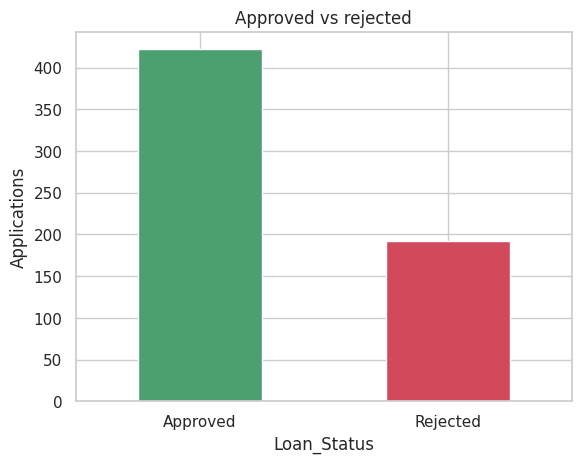

In [4]:
y = (df["Loan_Status"] == "Y").astype(int)        # 1 = approved, 0 = rejected
print(y.value_counts().rename({1: "Approved", 0: "Rejected"}))
print(f"\nApproval rate: {y.mean():.1%}")

y.value_counts().rename({1: "Approved", 0: "Rejected"}).plot(kind="bar", color=["#4C9F70", "#D1495B"])
plt.title("Approved vs rejected"); plt.ylabel("Applications"); plt.xticks(rotation=0); plt.show()

**Takeaway:** 69% of applications are approved. So a "model" that **always says approve** would already be about **69% accurate** without learning anything. Any real model has to beat that number, so I use it as the **baseline**.

### What do approved and rejected applications look like?

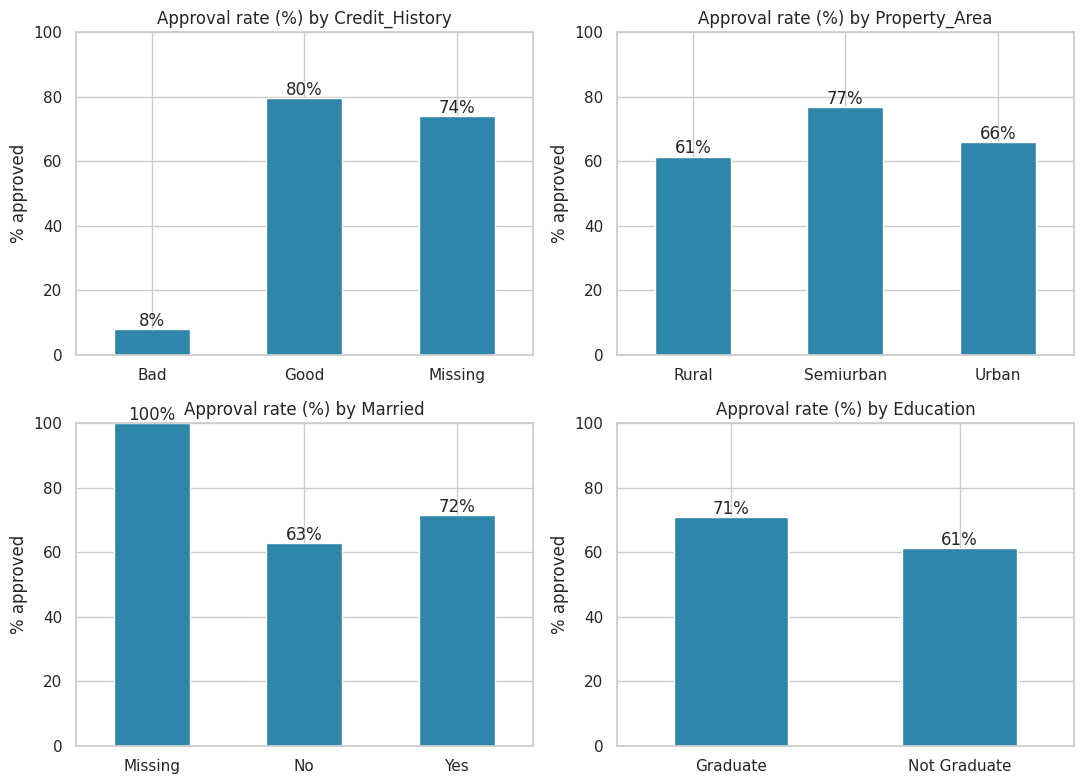

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.ravel(), ["Credit_History", "Property_Area", "Married", "Education"]):
    rate = (df.assign(approved=y, **{col: df[col].fillna("Missing")})
              .groupby(col)["approved"].mean() * 100)
    rate.plot(kind="bar", ax=ax, color="#2E86AB")
    ax.set_title(f"Approval rate (%) by {col}"); ax.set_ylabel("% approved"); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    for i, v in enumerate(rate.values):
        ax.text(i, v + 1, f"{v:.0f}%", ha="center")
    ax.set_ylim(0, 100)
plt.tight_layout(); plt.show()

**Takeaways**
- **Credit history is the big one:** about **80%** of applicants with good credit history are approved, versus only **8%** with bad history. Applicants with *missing* history are approved 74% of the time, close to the good group, which is why "Missing" is kept as its own category.
- Property area, marital status and education matter only a little (e.g. Semiurban 77% vs Rural 61%).

/tmp/ipykernel_155/1122811324.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df.assign(Loan_Status=df["Loan_Status"].map({"Y": "Approved", "N": "Rejected"})),


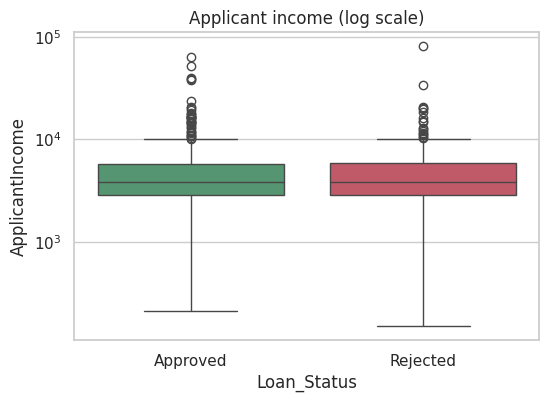

In [6]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df.assign(Loan_Status=df["Loan_Status"].map({"Y": "Approved", "N": "Rejected"})),
            x="Loan_Status", y="ApplicantIncome", palette=["#4C9F70", "#D1495B"], order=["Approved", "Rejected"])
plt.yscale("log"); plt.title("Applicant income (log scale)"); plt.show()

**Takeaway:** applicant income looks almost the same for approved and rejected applications (median ≈ 3,812 vs 3,834). Surprisingly, income by itself is not what drives the decision here.

## Step 4 — Split into training and test data

- **Training set (80%)** — the model learns from this.
- **Test set (20%)** — hidden until the end, to check performance on applications the model has *never seen*.

`stratify=y` keeps the same approval rate in both sets. I split **before** filling missing values so no information from the test set leaks into training.

In [7]:
X = df.drop(columns="Loan_Status")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

print("Training applications:", len(X_train), "| approval rate:", round(y_train.mean(), 3))
print("Test applications    :", len(X_test),  "| approval rate:", round(y_test.mean(), 3))

Training applications: 491 | approval rate: 0.686
Test applications    : 123 | approval rate: 0.691


## Step 5 — Prepare the data (one reusable recipe)

Models only understand numbers, so the recipe does three things:
1. **Number columns:** fill blanks with the median (and scale them for Logistic Regression).
2. **Text columns:** fill blanks with "Missing", then **one-hot encode** (e.g. `Property_Area` becomes three yes/no columns: Urban, Semiurban, Rural).
3. Everything is wrapped in a **Pipeline**, so the recipe is learned from the training data only and then applied identically to the test data.

In [8]:
num_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]
cat_cols = [c for c in X.columns if c not in num_cols]

def make_prep(scale):
    num_steps = [("fill", SimpleImputer(strategy="median"))]
    if scale:
        num_steps.append(("scale", StandardScaler()))
    return ColumnTransformer([
        ("num", Pipeline(num_steps), num_cols),
        ("cat", Pipeline([("fill", SimpleImputer(strategy="constant", fill_value="Missing")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
    ])

## Step 6 — Train the models

| Model | Why it is here |
|---|---|
| **Baseline** | "Always approve" — the number to beat |
| **Logistic Regression** | Simple, fast, and explainable: each feature gets a weight |
| **Decision Tree (depth 3)** | A short flowchart of yes/no questions — easy to draw and explain |
| **Random Forest** | Many trees voting together; usually more accurate but harder to explain |

I deliberately keep the trees small (`max_depth`) so they don't memorise the training data (**overfitting**).

In [9]:
models = {
    "Baseline (always approve)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": Pipeline([("prep", make_prep(True)), ("model", LogisticRegression(max_iter=1000))]),
    "Decision Tree (depth 3)": Pipeline([("prep", make_prep(False)), ("model", DecisionTreeClassifier(max_depth=3, random_state=SEED))]),
    "Random Forest": Pipeline([("prep", make_prep(False)), ("model", RandomForestClassifier(n_estimators=200, max_depth=5,
                                                                                           min_samples_leaf=5, random_state=SEED))]),
}
for model in models.values():
    model.fit(X_train, y_train)
print("All models trained.")

All models trained.


## Step 7 — Cross-validation: is the result stable?

The test set is small, so one split could be lucky. **5-fold cross-validation** splits the *training* data into 5 parts, trains on 4 and checks on 1, and rotates 5 times. If the 5 scores are similar, the model is stable.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
rows = []
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    rows.append({"Model": name, "CV accuracy (mean)": scores.mean(), "± std": scores.std()})
pd.DataFrame(rows).set_index("Model").round(3)

,CV accuracy (mean),± std
Model,,
Baseline (always approve),0.686,0.004
Logistic Regression,0.790,0.044
Decision Tree (depth 3),0.784,0.036
Random Forest,0.798,0.046


**Takeaway:** all three real models land around **79%–80%** accuracy, about 10 points above the 69% baseline. The differences *between* the three models (≈ 1 point) are much smaller than the fold-to-fold spread (± 5 points), so there is **no clear winner** on accuracy.

## Step 8 — Evaluate on the test set

| Metric | Question it answers (here, "positive" = approved) |
|---|---|
| **Accuracy** | Out of all applications, how many did we get right? |
| **Precision** | When we say *approve*, how often is that right? (low precision = bad loans get approved) |
| **Recall** | Of all applications that *should* be approved, how many did we approve? |
| **F1-score** | One number balancing precision and recall |
| **Rejections caught** | Of the applications that were *rejected*, how many did we correctly flag? |

In [11]:
def get_scores(name, model):
    pred = model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    return {"Model": name,
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred),
            "Recall": recall_score(y_test, pred),
            "F1-score": f1_score(y_test, pred),
            "Rejections caught": tn / (tn + fp)}

# a simple hand-made rule for comparison: approve if (and only if) credit history is good
rule_pred = (X_test["Credit_History"] == "Good").astype(int)
rule_row = {"Model": "Rule: approve if credit history is Good",
            "Accuracy": accuracy_score(y_test, rule_pred), "Precision": precision_score(y_test, rule_pred),
            "Recall": recall_score(y_test, rule_pred), "F1-score": f1_score(y_test, rule_pred),
            "Rejections caught": confusion_matrix(y_test, rule_pred)[0, 0] / (y_test == 0).sum()}

scores = pd.DataFrame([get_scores(n, m) for n, m in models.items()] + [rule_row]).set_index("Model")
scores.round(3)

,Accuracy,Precision,Recall,F1-score,Rejections caught
Model,,,,,
Baseline (always approve),0.691,0.691,1.000,0.817,0.000
Logistic Regression,0.862,0.840,0.988,0.908,0.579
Decision Tree (depth 3),0.846,0.824,0.988,0.898,0.526
Random Forest,0.854,0.832,0.988,0.903,0.553
Rule: approve if credit history is Good,0.797,0.819,0.906,0.860,0.553


**How to read this table**
- The **baseline** gets 69% accuracy and recall 1.00 by approving everyone, but it catches **0%** of rejections. Notice its F1 (0.82) still looks decent. That is exactly why a single number can mislead, and why I also look at *Rejections caught*.
- The three real models reach about 85%–86% accuracy with near-perfect recall, but they catch only 53%–58% of the rejections.
- **A one-line rule** ("approve if credit history is good") already reaches **80%** accuracy. The models improve on it by only a few points, on a test set of just 123 applications. That tells us how dominant credit history is.

### Confusion matrices

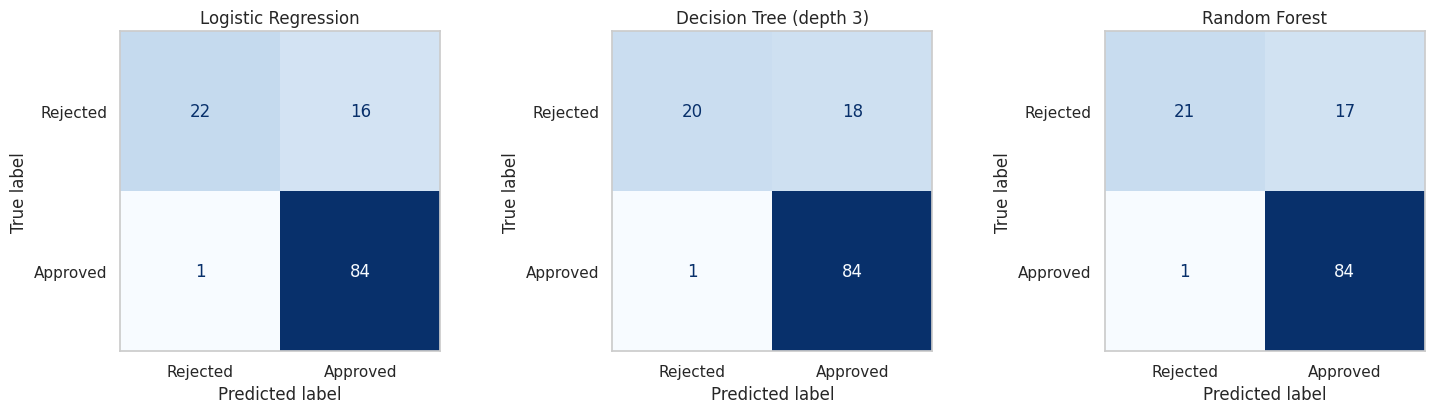

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, name in zip(axes, ["Logistic Regression", "Decision Tree (depth 3)", "Random Forest"]):
    cm = confusion_matrix(y_test, models[name].predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=["Rejected", "Approved"]).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(name); ax.grid(False)
plt.tight_layout(); plt.show()

**How to read a confusion matrix** (rows = what really happened, columns = what the model predicted):

| | Predicted: Rejected | Predicted: Approved |
|---|---|---|
| **Actually rejected** | True Negative ✅ | False Positive ❌ (**approved but should have been rejected — the risky mistake for a lender**) |
| **Actually approved** | False Negative ❌ (a good customer turned away) | True Positive ✅ |

For Logistic Regression: 84 approvals correct, 22 rejections correct, 16 risky approvals (false positives) and only 1 good customer wrongly rejected. The models are good at spotting applications to approve, and much weaker at spotting the ones to reject, which is the part a lender cares about.

## Step 9 — Why does the model decide this way?

### The decision tree: a flowchart you can read out loud

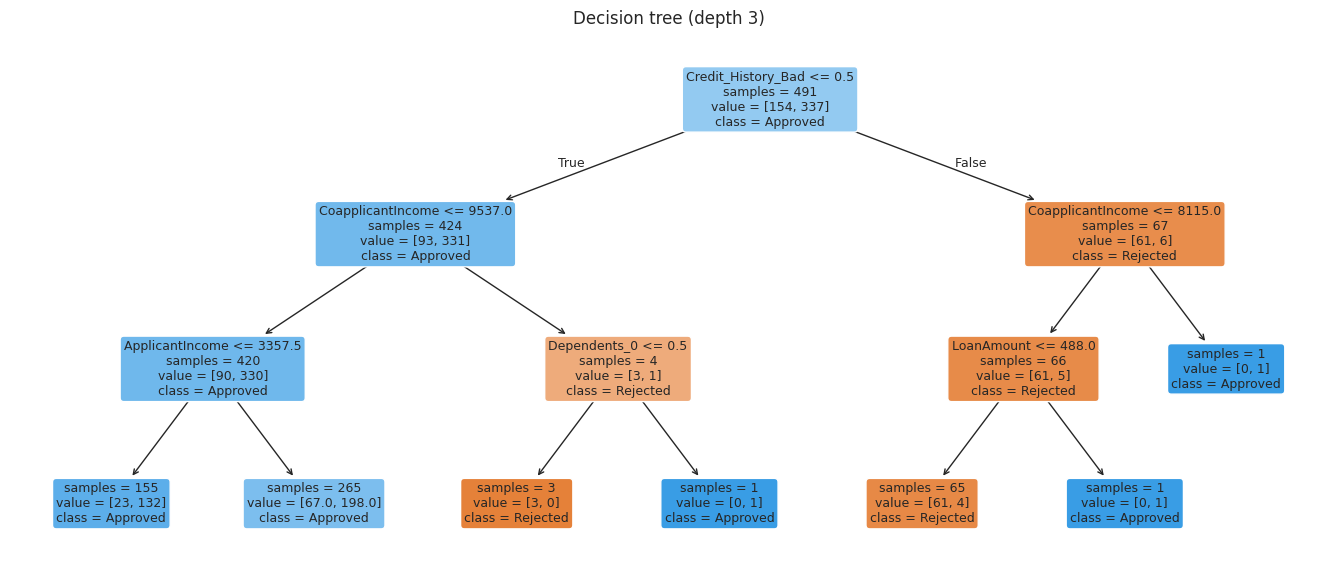

In [13]:
tree_prep = models["Decision Tree (depth 3)"].named_steps["prep"]
tree = models["Decision Tree (depth 3)"].named_steps["model"]
feature_names = [n.split("__", 1)[1] for n in tree_prep.get_feature_names_out()]

plt.figure(figsize=(17, 7))
plot_tree(tree, feature_names=feature_names, class_names=["Rejected", "Approved"],
          filled=True, rounded=True, fontsize=9, impurity=False)
plt.title("Decision tree (depth 3)"); plt.show()

**How to read the tree:** start at the top box and follow the arrows. Each box shows the question, how many training applications reached it (`samples`), the split of outcomes (`value = [rejected, approved]`), and the majority outcome (`class`). For a yes/no column such as `Credit_History_Bad`, "`<= 0.5`" simply means **No** (so the left arrow = credit history is *not* bad).

The first question is about **credit history**, which matches the exploration, and almost every large box below it just repeats the same verdict. In practice this tree behaves like the one-line credit-history rule with a few small refinements. It is the easiest model to explain to a non-technical person.

### Logistic Regression: which factors push towards approval?

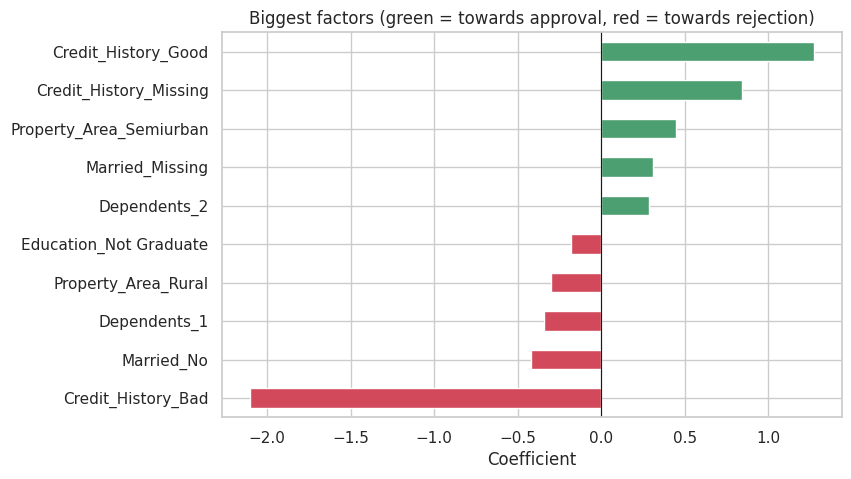

In [14]:
lr_prep = models["Logistic Regression"].named_steps["prep"]
lr_model = models["Logistic Regression"].named_steps["model"]
names = [n.split("__", 1)[1] for n in lr_prep.get_feature_names_out()]
coefs = pd.Series(lr_model.coef_[0], index=names).sort_values()

top = pd.concat([coefs.head(5), coefs.tail(5)])
top.plot(kind="barh", color=["#D1495B" if v < 0 else "#4C9F70" for v in top], figsize=(8, 5))
plt.axvline(0, color="k", lw=.8)
plt.title("Biggest factors (green = towards approval, red = towards rejection)"); plt.xlabel("Coefficient"); plt.show()

**Takeaway:** the strongest push towards approval is **`Credit_History_Good`** and the strongest push towards rejection is **`Credit_History_Bad`**. Income-related features have small weights. This agrees with the exploration: credit history dominates.

(For one-hot columns like `Credit_History_Good`, the weight says how much that category moves the decision compared with the other categories of the same feature.)

### A fairness check: does the model need Gender and Marital status?

In [15]:
cols_no_protected = [c for c in cat_cols if c not in ["Gender", "Married"]]
prep_np = ColumnTransformer([
    ("num", Pipeline([("fill", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), num_cols),
    ("cat", Pipeline([("fill", SimpleImputer(strategy="constant", fill_value="Missing")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cols_no_protected)])
model_np = Pipeline([("prep", prep_np), ("model", LogisticRegression(max_iter=1000))])

with_all = cross_val_score(models["Logistic Regression"], X_train, y_train, cv=cv, scoring="accuracy")
without = cross_val_score(model_np, X_train.drop(columns=["Gender", "Married"]), y_train, cv=cv, scoring="accuracy")
print(f"CV accuracy WITH Gender & Married   : {with_all.mean():.3f} ± {with_all.std():.3f}")
print(f"CV accuracy WITHOUT Gender & Married: {without.mean():.3f} ± {without.std():.3f}")

CV accuracy WITH Gender & Married   : 0.790 ± 0.044
CV accuracy WITHOUT Gender & Married: 0.800 ± 0.042


**Takeaway:** removing Gender and Marital status changes accuracy by about 1.0 points, well within the fold-to-fold spread, so the model does not really need them. In real lending, using personal characteristics such as gender in credit decisions is restricted and risky, so being able to drop them at no cost is a good sign.

## Step 10 — Use the model on new applicants

In [16]:
new_applicants = pd.DataFrame({
    "Gender": ["Male", "Female", "Male"], "Married": ["Yes", "No", "Yes"], "Dependents": ["1", "0", "2"],
    "Education": ["Graduate", "Graduate", "Not Graduate"], "Self_Employed": ["No", "No", "Yes"],
    "ApplicantIncome": [5000, 3500, 4000], "CoapplicantIncome": [1500, 0, 1000],
    "LoanAmount": [130, 120, 160], "Loan_Amount_Term": [360, 360, 360],
    "Credit_History": ["Good", "Bad", "Good"], "Property_Area": ["Semiurban", "Urban", "Rural"],
})
best = models["Logistic Regression"]
new_applicants["P(approved)"] = best.predict_proba(new_applicants)[:, 1].round(2)
new_applicants["Decision"] = np.where(new_applicants["P(approved)"] >= 0.5, "Approve", "Reject")
new_applicants[["Credit_History", "ApplicantIncome", "LoanAmount", "Property_Area", "P(approved)", "Decision"]]

,Credit_History,ApplicantIncome,LoanAmount,Property_Area,P(approved),Decision
0,Good,5000,130,Semiurban,0.85,Approve
1,Bad,3500,120,Urban,0.10,Reject
2,Good,4000,160,Rural,0.74,Approve


## Step 11 — Conclusions & limitations

**Conclusions**
- Credit history is by far the strongest signal: ~80% approval with good history vs ~8% with bad history. Income barely differs between approved and rejected applications.
- All three models beat the 69% "always approve" baseline by roughly 10–15 points (about 79%–80% in cross-validation, up to 86% on the test set), but they improve on the simple credit-history rule (80% on the test set) by only a few points.
- Since the models perform similarly, I would choose **Logistic Regression** (or the small tree) because it is simple and explainable, which matters in lending.

**Limitations (say these in an interview)**
- Small dataset (614 applications, 123 in the test set), so accuracy numbers are only accurate to a few points. The test accuracy (86%) is higher than the cross-validation accuracy (79%), which is a reminder that a single small test set can be a bit lucky.
- The label is the lender's **past decision**, not whether the borrower repaid, so the model copies past behaviour, including any bias in it.
- The models catch only about 53%–58% of rejections; before real use I would look at precision/recall trade-offs and the cost of a bad approval.
- Little tuning was done; the goal here is a clear, correct pipeline rather than the highest score.

---
# 🎤 Interview cheat sheet

## 60-second pitch
> "I built a loan-approval classifier on 614 loan applications. Only about 69% are approved, so I first set a baseline: always predicting 'approve' is already 69% accurate. I split the data 80/20 with stratification, filled missing values and encoded categories inside a pipeline, and trained Logistic Regression, a small Decision Tree and a Random Forest. With 5-fold cross-validation they all scored about 79%, and on the test set they reached 85%–86%. The most interesting finding was that credit history dominates: a one-line rule on credit history already gets 80%. I evaluated with accuracy, precision, recall, F1 and a confusion matrix, noticed the models are weak at catching rejections, and chose Logistic Regression because it is simple and explainable."

## Likely questions & simple answers

**What is classification?**
Predicting a category (approved / rejected) instead of a number.

**Why is your baseline important?**
About 69% of loans are approved, so "always approve" is 69% accurate without learning anything. A model is only useful if it beats that.

**Explain precision and recall here.**
Precision: *when the model says approve, how often is that right?* Recall: *of the applications that deserved approval, how many did the model approve?*

**Which mistake is worse for a lender?**
Usually approving a loan that should have been rejected (false positive). That is why I looked at how many rejections the model catches, not only accuracy.

**What is a confusion matrix?**
A 2×2 table of right and wrong predictions: true/false positives and negatives. It shows *which kind* of mistake the model makes.

**How did you handle missing values?**
Median for numeric columns, and a separate "Missing" category for text columns. I did it inside a pipeline after the train/test split so no test information leaks into training.

**What is one-hot encoding?**
Models need numbers, so a category like Property_Area becomes separate yes/no columns (Urban, Semiurban, Rural).

**Why split into train and test? Why stratify?**
To check the model on applications it has never seen. Stratify keeps the same approval rate in both sets.

**Why did you limit the depth of the tree?**
A deep tree memorises the training data (overfitting) and does worse on new data. A shallow tree also stays readable.

**Why Logistic Regression?**
The three models performed about the same, so I picked the simplest and most explainable one. In lending you often have to explain why someone was rejected.

**What does cross-validation add?**
The test set is small, so one split can be lucky. Cross-validation trains and checks on 5 different splits, showing how stable the score is.

**Is it okay to use gender or marital status?**
In real lending these are sensitive and often restricted. I checked that dropping them barely changes accuracy (0.790 with vs 0.800 without in cross-validation), so the model doesn't need them.

**What are the limitations?**
Small dataset, the label is a past decision rather than repayment, and the model only modestly beats a simple credit-history rule.

**How would you improve it?**
More data, the repayment outcome as the target, feature engineering (e.g. loan-to-income ratio), hyperparameter tuning, and a cost-based threshold for approvals.